In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from warnings import filterwarnings
filterwarnings(action='ignore')

In [2]:
# Load the dataset
iris = pd.read_csv("iris.csv")

In [3]:
# Data Inspection
print(iris.shape)
print(iris.describe())
print(iris.isna().sum())
print(iris.head())

(150, 6)
               Id  sepal-length  sepal-width  petal-length  petal-width
count  150.000000    150.000000   150.000000    150.000000   150.000000
mean    75.500000      5.843333     3.054000      3.758667     1.198667
std     43.445368      0.828066     0.433594      1.764420     0.763161
min      1.000000      4.300000     2.000000      1.000000     0.100000
25%     38.250000      5.100000     2.800000      1.600000     0.300000
50%     75.500000      5.800000     3.000000      4.350000     1.300000
75%    112.750000      6.400000     3.300000      5.100000     1.800000
max    150.000000      7.900000     4.400000      6.900000     2.500000
Id              0
sepal-length    0
sepal-width     0
petal-length    0
petal-width     0
species         0
dtype: int64
   Id  sepal-length  sepal-width  petal-length  petal-width      species
0   1           5.1          3.5           1.4          0.2  Iris-setosa
1   2           4.9          3.0           1.4          0.2  Iris-setosa
2  

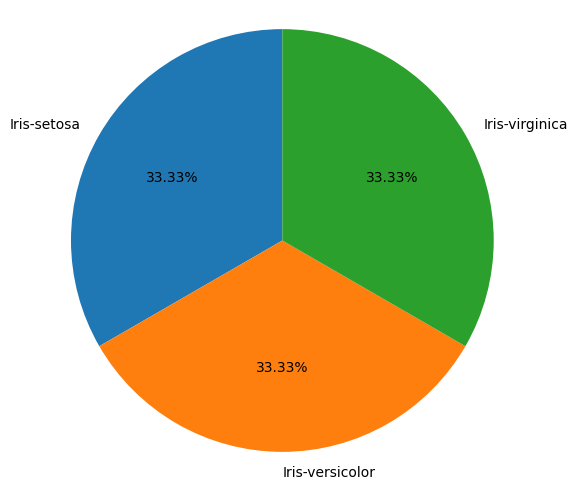

In [4]:
# Pie Chart for Species distribution
plt.figure(figsize=(6,6))
species_counts = iris['species'].value_counts()
plt.pie(species_counts, labels=species_counts.index, autopct='%1.2f%%', startangle=90)
plt.axis('equal')
plt.show()

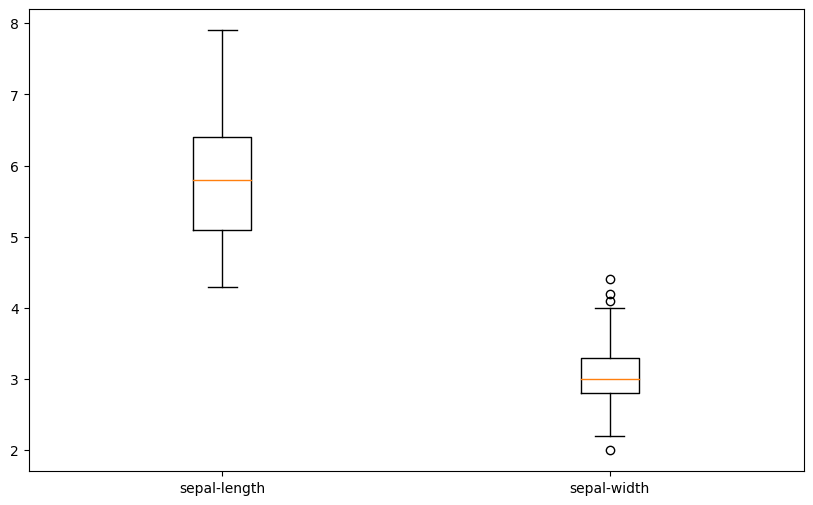

In [5]:
# Checking for outliers using boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([iris['sepal-length'], iris['sepal-width']], labels=['sepal-length', 'sepal-width'])
plt.show()

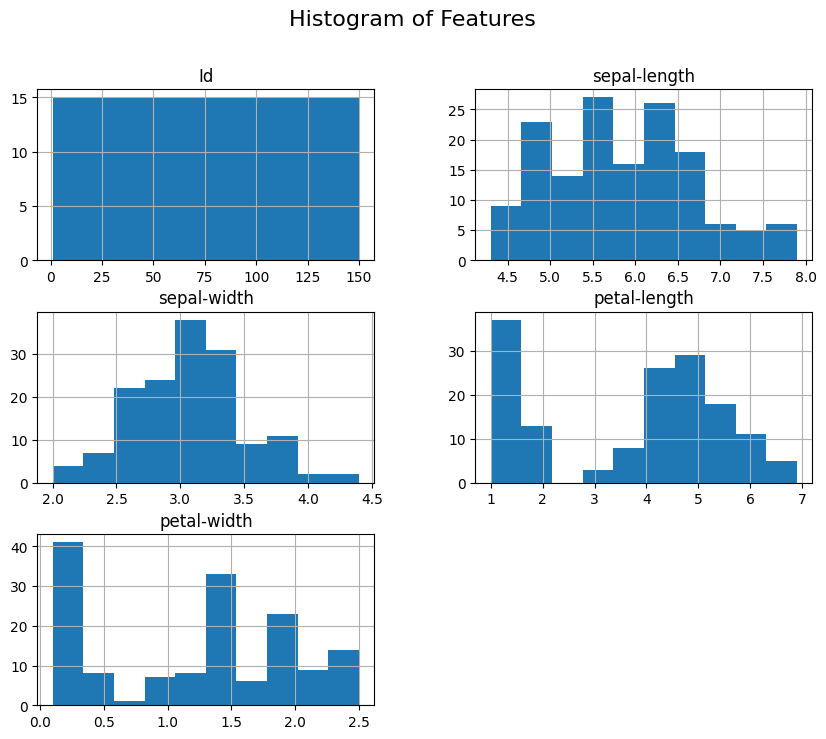

Id                 Axes(0.125,0.53;0.133621x0.35)
sepal-length    Axes(0.285345,0.53;0.133621x0.35)
sepal-width      Axes(0.44569,0.53;0.133621x0.35)
petal-length    Axes(0.606034,0.53;0.133621x0.35)
petal-width     Axes(0.766379,0.53;0.133621x0.35)
dtype: object

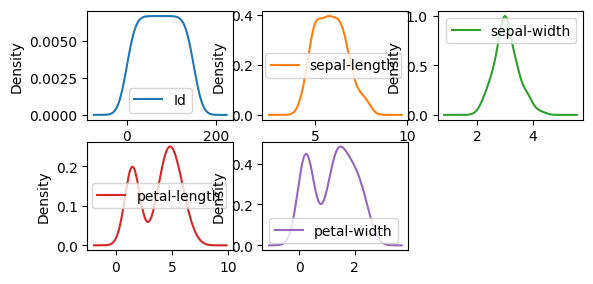

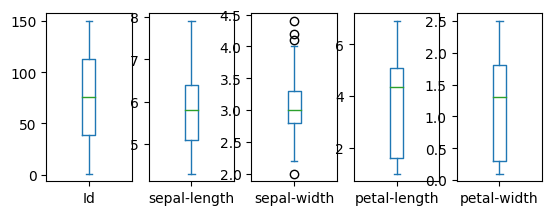

In [6]:
# Histogram and density plots
iris.hist(figsize=(10, 8))
plt.suptitle("Histogram of Features", fontsize=16)
plt.show()

# Optional: Density plot and box plot in separate cells if necessary
iris.plot(kind='density', subplots=True, layout=(3, 3), sharex=False)
iris.plot(kind='box', subplots=True, layout=(2, 5), sharex=False)

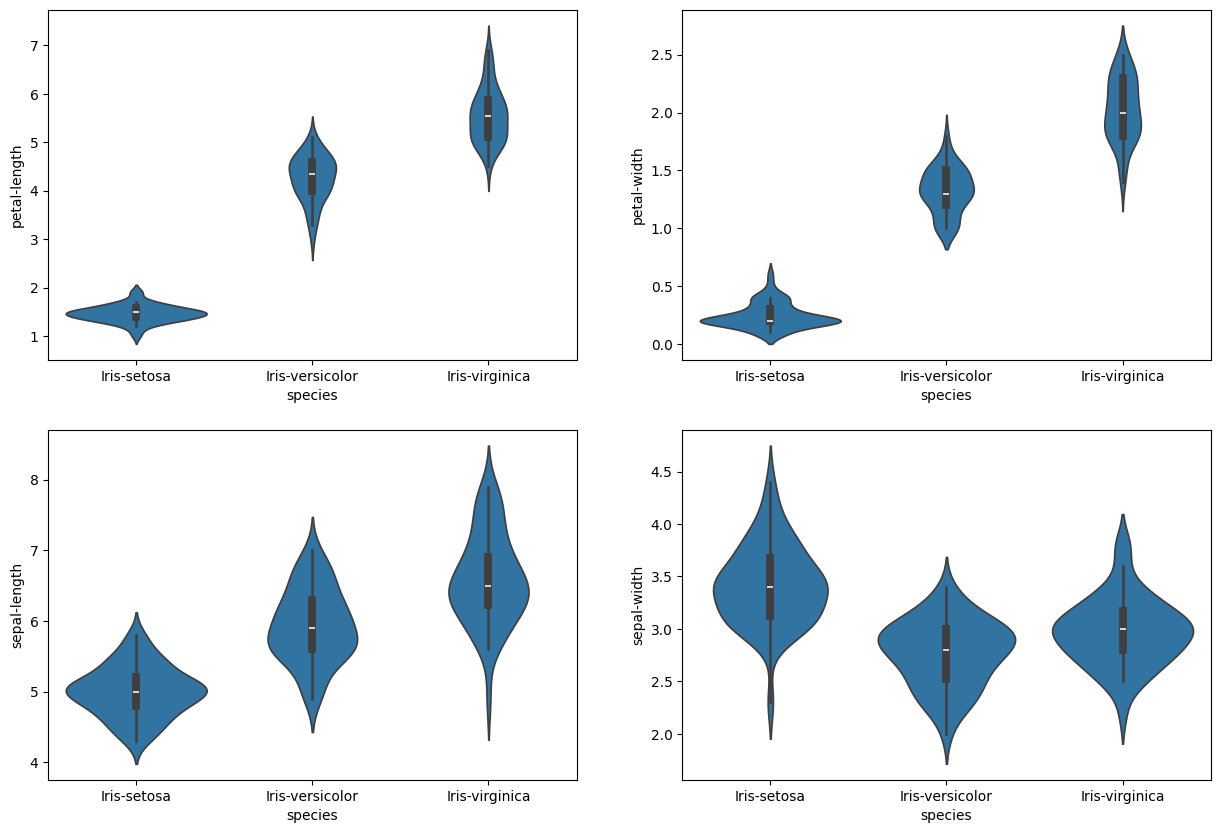

In [7]:
# Violin plots for different features
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.violinplot(x='species', y='petal-length', data=iris)
plt.subplot(2, 2, 2)
sns.violinplot(x='species', y='petal-width', data=iris)
plt.subplot(2, 2, 3)
sns.violinplot(x='species', y='sepal-length', data=iris)
plt.subplot(2, 2, 4)
sns.violinplot(x='species', y='sepal-width', data=iris)
plt.show()

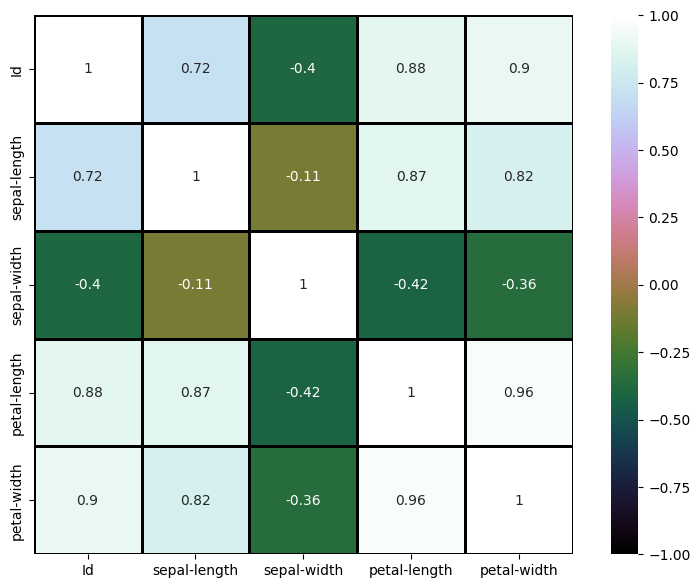

In [8]:
# Heatmap of correlations (excluding 'species' column which is categorical)
fig = plt.gcf()
fig.set_size_inches(10, 7)

# Selecting only numeric columns for the correlation matrix
numeric_iris = iris.select_dtypes(include=[np.number])

# Generate the heatmap
sns.heatmap(numeric_iris.corr(), annot=True, cmap='cubehelix', linewidths=1, linecolor='k', square=True, vmin=-1, vmax=1, cbar_kws={"orientation": "vertical"}, cbar=True)
plt.show()

In [9]:
# Splitting data into training and testing sets
train, test = train_test_split(iris, test_size=0.25, random_state=42)

# Prepare features and target variables
train_X = train[['sepal-length', 'sepal-width', 'petal-length', 'petal-width']]
train_y = train['species']
test_X = test[['sepal-length', 'sepal-width', 'petal-length', 'petal-width']]
test_y = test['species']

# Checking the shapes of train and test sets
print(train.shape)
print(test.shape)

(112, 6)
(38, 6)


In [10]:
# Logistic Regression Model
model = LogisticRegression(max_iter=200)
model.fit(train_X, train_y)
prediction = model.predict(test_X)
print('Logistic Regression Accuracy:', accuracy_score(test_y, prediction))

# Support Vector Machine (SVM)
model1 = SVC()
model1.fit(train_X, train_y)
pred_y = model1.predict(test_X)
print("SVM Accuracy =", accuracy_score(test_y, pred_y))

# k-Nearest Neighbors (KNN)
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(train_X, train_y)
y_pred2 = model2.predict(test_X)
print("KNN Accuracy Score:", accuracy_score(test_y, y_pred2))

# Naive Bayes
model3 = GaussianNB()
model3.fit(train_X, train_y)
y_pred3 = model3.predict(test_X)
print("Naive Bayes Accuracy Score:", accuracy_score(test_y, y_pred3))

# Decision Tree
model4 = DecisionTreeClassifier(criterion='entropy', random_state=7)
model4.fit(train_X, train_y)
y_pred4 = model4.predict(test_X)
print("Decision Tree Accuracy Score:", accuracy_score(test_y, y_pred4))

# Random Forest Classifier
model5 = RandomForestClassifier(n_estimators=100, random_state=42)
model5.fit(train_X, train_y)
y_pred5 = model5.predict(test_X)
print("Random Forest Accuracy Score:", accuracy_score(test_y, y_pred5))

Logistic Regression Accuracy: 1.0
SVM Accuracy = 1.0
KNN Accuracy Score: 1.0
Naive Bayes Accuracy Score: 1.0
Decision Tree Accuracy Score: 0.9736842105263158
Random Forest Accuracy Score: 1.0


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Example: Label encode the target variable (train_y)
label_encoder = LabelEncoder()
train_y_encoded = label_encoder.fit_transform(train_y)

# Linear Regression Model (using only 'petal-length' as an example for regression)
linear_model = LinearRegression()
linear_model.fit(train_X[['petal-length']], train_y_encoded)

# Make predictions
regression_prediction = linear_model.predict(test_X[['petal-length']])

predicted_classes = label_encoder.inverse_transform(regression_prediction.round().astype(int))

# Print results
print('Linear Regression Accuracy:', accuracy_score(test_y, predicted_classes))

Linear Regression Accuracy: 1.0


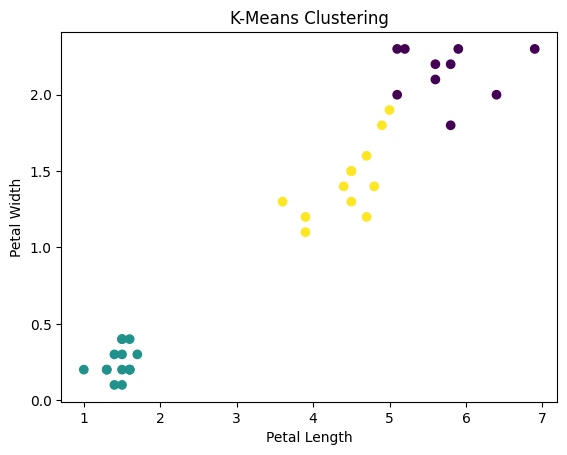

In [12]:
# Applying K-Means for clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(train_X)
cluster_labels = kmeans.predict(test_X)

# Visualizing the clustering
plt.scatter(test_X['petal-length'], test_X['petal-width'], c=cluster_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

In [13]:
# Example of hyperparameter tuning for KNN using GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(train_X, train_y)

# Best Parameters and Model Evaluation
best_model = grid_search.best_estimator_
print("Best KNN Model Parameters:", grid_search.best_params_)
best_pred = best_model.predict(test_X)
print("Best KNN Model Accuracy: ", accuracy_score(test_y, best_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN Model Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN Model Accuracy:  1.0


In [14]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset (using the Iris dataset for demonstration)
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Labels (species)

# Split the dataset into training and testing sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=42)

# Store models and their corresponding accuracy scores in a dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=7),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train each model and record the accuracy
model_accuracies = {}

for model_name, model in models.items():
    model.fit(train_X, train_y)  # Train the model
    prediction = model.predict(test_X)  # Make predictions on the test set
    accuracy = accuracy_score(test_y, prediction)  # Calculate accuracy
    model_accuracies[model_name] = accuracy
    print(f"{model_name} Accuracy: {accuracy}")

# Find the best model based on accuracy
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model_accuracy = model_accuracies[best_model_name]
print(f"\nBest Model: {best_model_name} with Accuracy: {best_model_accuracy}")


Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0
KNN Accuracy: 1.0
Naive Bayes Accuracy: 0.9777777777777777
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0

Best Model: Logistic Regression with Accuracy: 1.0


In [15]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def predict_flower_species():
    # Load the Iris dataset for demonstration
    iris = load_iris()
    X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
    y = iris.target  # Labels (species)
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    
    # User inputs
    sepal_length = float(input("Enter sepal length (cm): "))
    sepal_width = float(input("Enter sepal width (cm): "))
    petal_length = float(input("Enter petal length (cm): "))
    petal_width = float(input("Enter petal width (cm): "))
    
    # Prepare the input data in the format expected by the model (as a 2D array)
    user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Predict the species using the trained logistic regression model
    prediction = model.predict(user_input)
    
    # Convert the numeric prediction to the actual species name
    species = iris.target_names[prediction][0]
    
    # Print the result
    print(f"The predicted flower species is: {species}")

# Call the function to predict species
predict_flower_species()

Enter sepal length (cm):  2
Enter sepal width (cm):  3
Enter petal length (cm):  2
Enter petal width (cm):  3


The predicted flower species is: setosa


Enter sepal length (cm):  3
Enter sepal width (cm):  6
Enter petal length (cm):  3
Enter petal width (cm):  9


The predicted flower species is: virginica


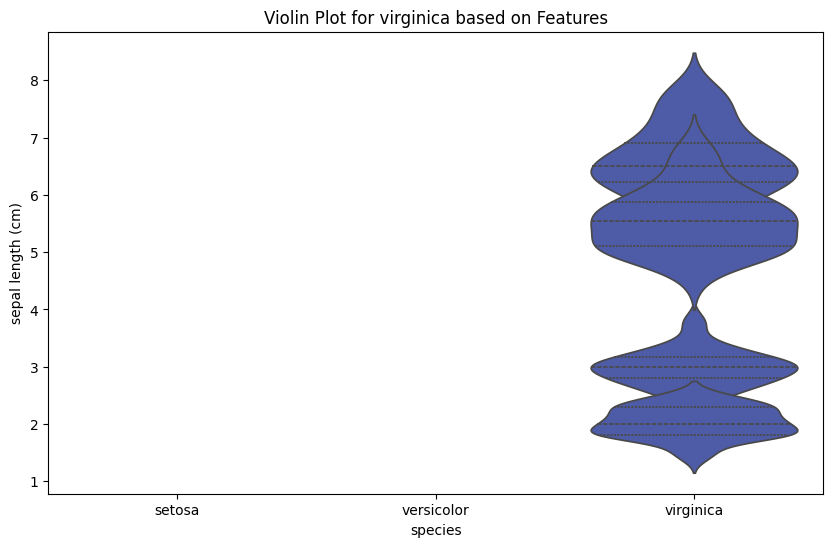

In [19]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Load the iris dataset and train a model
iris = load_iris()
X = iris.data
y = iris.target

# Train a Logistic Regression model on the dataset
model = LogisticRegression(max_iter=200)
model.fit(X, y)

# Define color palette for each species with representative iris flower colors
species_colors = {
    'setosa': '#51c6b3',       # Setosa color (dark purple sepals, lighter purple petals)
    'versicolor': '#B39DDB',    # Versicolor color (lavender purple sepals and petals)
    'virginica': '#3F51B5'     # Virginica color (deep blue sepals, light blue petals)
}

def predict_flower_species():
    # User inputs
    sepal_length = float(input("Enter sepal length (cm): "))
    sepal_width = float(input("Enter sepal width (cm): "))
    petal_length = float(input("Enter petal length (cm): "))
    petal_width = float(input("Enter petal width (cm): "))

    # Prepare the input data in the format expected by the model (as a 2D array)
    user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Predict the species using the trained logistic regression model
    prediction = model.predict(user_input)
    predicted_species = prediction[0]
    
    # Map the predicted species to the species name
    species_names = iris.target_names
    predicted_species_name = species_names[predicted_species]
    
    # Print the result
    print(f"The predicted flower species is: {predicted_species_name}")

    # Create a DataFrame for visualization
    df = pd.DataFrame(X, columns=iris.feature_names)
    df['species'] = pd.Categorical.from_codes(y, species_names)

    # Filter the DataFrame to only include the predicted species
    df_filtered = df[df['species'] == predicted_species_name]

    # Plot a violin plot for the predicted species
    plt.figure(figsize=(10, 6))

    # Plot each feature separately for the filtered species
    sns.violinplot(x='species', y='sepal length (cm)', data=df_filtered, inner="quart", palette=[species_colors[predicted_species_name]])
    sns.violinplot(x='species', y='sepal width (cm)', data=df_filtered, inner="quart", palette=[species_colors[predicted_species_name]])
    sns.violinplot(x='species', y='petal length (cm)', data=df_filtered, inner="quart", palette=[species_colors[predicted_species_name]])
    sns.violinplot(x='species', y='petal width (cm)', data=df_filtered, inner="quart", palette=[species_colors[predicted_species_name]])

    plt.title(f"Violin Plot for {predicted_species_name} based on Features")
    plt.show()

# Call the function to predict species
predict_flower_species()


In [20]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Apply StandardScaler to the training and test sets
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

# 1. Hyperparameter Tuning for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=2)
grid_search_knn.fit(train_X_scaled, train_y)

# Best KNN Model and Evaluation
best_knn_model = grid_search_knn.best_estimator_
print("Best KNN Model Parameters:", grid_search_knn.best_params_)
best_knn_pred = best_knn_model.predict(test_X_scaled)
print("Best KNN Model Accuracy: ", accuracy_score(test_y, best_knn_pred))

# 2. Hyperparameter Tuning for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 300]
}

grid_search_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, n_jobs=-1, verbose=2)
grid_search_lr.fit(train_X_scaled, train_y)

# Best Logistic Regression Model and Evaluation
best_lr_model = grid_search_lr.best_estimator_
print("Best Logistic Regression Parameters:", grid_search_lr.best_params_)
best_lr_pred = best_lr_model.predict(test_X_scaled)
print("Best Logistic Regression Accuracy: ", accuracy_score(test_y, best_lr_pred))

# 3. Hyperparameter Tuning for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, n_jobs=-1, verbose=2)
grid_search_svm.fit(train_X_scaled, train_y)

# Best SVM Model and Evaluation
best_svm_model = grid_search_svm.best_estimator_
print("Best SVM Parameters:", grid_search_svm.best_params_)
best_svm_pred = best_svm_model.predict(test_X_scaled)
print("Best SVM Accuracy: ", accuracy_score(test_y, best_svm_pred))

# 4. Hyperparameter Tuning for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(train_X_scaled, train_y)

# Best Random Forest Model and Evaluation
best_rf_model = grid_search_rf.best_estimator_
print("Best Random Forest Parameters:", grid_search_rf.best_params_)
best_rf_pred = best_rf_model.predict(test_X_scaled)
print("Best Random Forest Accuracy: ", accuracy_score(test_y, best_rf_pred))

# 5. Cross-Validation for All Models
# Cross-validation for KNN
knn_cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean'), train_X_scaled, train_y, cv=5)
print(f"KNN Cross-Validation Accuracy: {knn_cv_scores.mean()}")

# Cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(LogisticRegression(C=1, solver='liblinear', max_iter=200), train_X_scaled, train_y, cv=5)
print(f"Logistic Regression Cross-Validation Accuracy: {lr_cv_scores.mean()}")

# Cross-validation for SVM
svm_cv_scores = cross_val_score(SVC(C=1, kernel='linear', gamma='scale'), train_X_scaled, train_y, cv=5)
print(f"SVM Cross-Validation Accuracy: {svm_cv_scores.mean()}")

# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=20), train_X_scaled, train_y, cv=5)
print(f"Random Forest Cross-Validation Accuracy: {rf_cv_scores.mean()}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN Model Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best KNN Model Accuracy:  1.0
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Logistic Regression Parameters: {'C': 100, 'max_iter': 100, 'solver': 'saga'}
Best Logistic Regression Accuracy:  1.0
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM Accuracy:  0.9777777777777777
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest Accuracy:  1.0
KNN Cross-Validation Accuracy: 0.9428571428571428
Logistic Regression Cross-Validation Accuracy: 0.8857142857142856
SVM Cross-Validation Accuracy: 0.9428571428571428
Random Forest Cross-Validation Accuracy: 0.9428571428571428
